In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import torch
import torch.nn.functional as F
import random
import numpy as np
import matplotlib.pyplot as plt

import util_data

## Create dataset

In [2]:
class transition_dataset(torch.utils.data.Dataset):
    def __init__(self, states, actions, next_states):
        self.states = states
        self.actions = actions
        self.targets = next_states - states  # delta

    def __len__(self):
        return len(self.states)

    def __getitem__(self, idx):
        return self.states[idx], self.actions[idx], self.targets[idx]

def bootstrap_indices(n, size):
    return np.random.choice(n, size=size, replace=True)

def normalize_standard(timeseries, mean, std):
    return (timeseries - mean) / std

skip_nsample = 150
data_nsample = 10_000 - skip_nsample
data = util_data.read_datafile('../../data/mujoco/hopper_all_0', data_nsample)
print(f'read data shape: {data.shape}')

state_ndim = 11
action_ndim = 3
states, actions = torch.split(data, [state_ndim, action_ndim], dim=-1)
print(f'read states shape: {states.shape}')
print(f'read actions shape: {actions.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

s_mean = [s.mean() for s in torch.split(states, 1, dim=-1)]
s_std = [torch.maximum(s.std(), std_min) for s in torch.split(states, 1, dim=-1)]
a_mean = [a.mean() for a in torch.split(actions, 1, dim=-1)]
a_std = [torch.maximum(a.std(), std_min) for a in torch.split(actions, 1, dim=-1)]

states = torch.cat([
    normalize_standard(s, mean, std) for s, mean, std in zip(torch.split(states, 1, dim=-1), s_mean, s_std)], dim=-1)

action = torch.cat([
    normalize_standard(a, mean, std) for a, mean, std in zip(torch.split(actions, 1, dim=-1), a_mean, a_std)], dim=-1)

train_states = states[0, :-1]
train_next_states = states[0, 1:]
train_actions = actions[0, :-1]
print(f'states for training shape: {train_states.shape}')
print(f'next states for training shape: {train_next_states.shape}')
print(f'action for training shape: {train_actions.shape}')

dataloaders = []
nmodel = 5

for _ in range(nmodel):
    dataset = transition_dataset(train_states, train_actions, train_next_states)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))


read data shape: torch.Size([1, 9850, 14])
read states shape: torch.Size([1, 9850, 11])
read actions shape: torch.Size([1, 9850, 3])
states for training shape: torch.Size([9849, 11])
next states for training shape: torch.Size([9849, 11])
action for training shape: torch.Size([9849, 3])


In [3]:
class dynamics(torch.nn.Module):
    def __init__(self, s_ndim, a_ndim, hidden=256):
        super().__init__()

        self.net = torch.nn.Sequential(
            torch.nn.Linear(s_ndim + a_ndim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
        )

        self.mean = torch.nn.Linear(hidden, s_ndim)
        self.logvar = torch.nn.Linear(hidden, s_ndim)

        # --! PETS trick: learned bounds
        self.max_logvar = torch.nn.Parameter(torch.ones(s_ndim) * 0.5)
        self.min_logvar = torch.nn.Parameter(torch.ones(s_ndim) * -10)

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        h = self.net(x)

        mean = self.mean(h)
        logvar = self.logvar(h)

        # --! variance clipping
        logvar = self.max_logvar - F.softplus(self.max_logvar - logvar)
        logvar = self.min_logvar + F.softplus(logvar - self.min_logvar)

        return mean, logvar

class ensemble_model:
    def __init__(self, nmodel, s_ndim, a_ndim):
        self.models = [
            dynamics(s_ndim, a_ndim)
            for _ in range(nmodel)
        ]

    def parameters(self):
        params = []
        for m in self.models:
            params += list(m.parameters())
        return params

In [29]:
def loss_fn(mean, logvar, target):
    """Computes Gaussian negative log likelihood."""
    inv_var = torch.exp(-logvar)
    mse = (mean - target) ** 2
    return torch.mean(mse * inv_var + logvar)

def train_ensemble(ensemble, dataloaders, nepoch=50):

    optimizers = [
        torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-8)
        for m in ensemble.models
    ]

    for epoch in range(nepoch):
        model_losses = [np.zeros(1) for _ in range(len(ensemble.models))]

        for model, dataloader, opt, model_loss in zip(ensemble.models, dataloaders, optimizers, model_losses):
            for s, a, target in dataloader:
                opt.zero_grad()

                mean, logvar = model(s, a)
                loss = loss_fn(mean, logvar, target)

                loss.backward()
                opt.step()

                model_loss[0] += loss.item()

        for model_loss in model_losses:
            model_loss[0] /= len(ensemble.models)
        if epoch % 10 == 0:
            print(epoch, model_losses)

def step_deterministic(ensemble, s, a):
    preds = []

    for m in ensemble.models:
        mean, _ = m(s, a)
        preds.append(mean)

    mean = torch.stack(preds).mean(0)
    return s + mean

def step_stochastic(ensemble, s, a):

    m = random.choice(ensemble.models)

    mean, logvar = m(s, a)

    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)

    delta = mean + eps * std

    return s + delta

def rollout(ensemble, s0, actions):
    states = [s0]
    s = s0

    for a in actions:
        s = step_deterministic(ensemble, s, a)

        states.append(s)

    return torch.stack(states)

In [5]:
s_ndim = 11
a_ndim = 3

model = ensemble_model(nmodel, s_ndim, a_ndim)
train_ensemble(model, dataloaders, nepoch=300)

0 [array([-45.05209531]), array([-46.22782176]), array([-46.51261049]), array([-47.6455293]), array([-48.6454397])]
10 [array([-94.13522283]), array([-98.10866604]), array([-81.59204005]), array([-93.55521734]), array([-98.24051158])]
20 [array([-109.38986206]), array([-112.2482254]), array([-108.85718818]), array([-110.72240381]), array([-112.54920135])]
30 [array([-117.43416252]), array([-116.36707573]), array([-116.13846264]), array([-118.90410318]), array([-117.19174383])]
40 [array([-123.33573666]), array([-120.4587841]), array([-121.41496124]), array([-122.63040504]), array([-124.53009958])]
50 [array([-126.85991392]), array([-126.57832146]), array([-126.36266623]), array([-126.75172739]), array([-128.67845058])]
60 [array([-129.5617095]), array([-129.91815162]), array([-127.58767042]), array([-127.85918446]), array([-129.77723131])]
70 [array([-135.01657457]), array([-135.38221254]), array([-131.27108173]), array([-134.01945868]), array([-135.95943089])]
80 [array([-136.13957844

In [30]:
s0 = states[0, 0]
rollout_traj = rollout(model, s0, actions[0])
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([9851, 11])


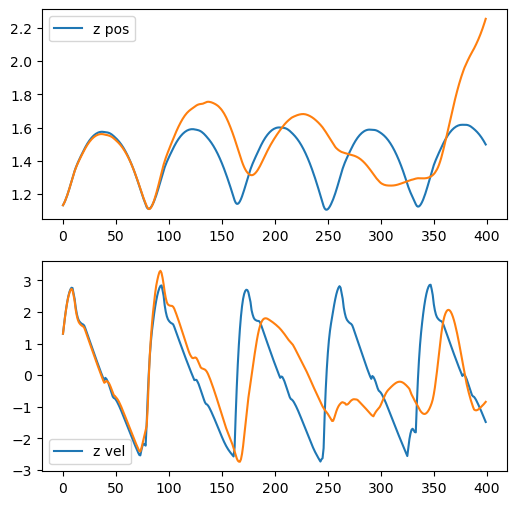

In [34]:
def denormalize_standard(timeseries, mean, std):
    return timeseries * std + mean

disp_end = 400
datasaved = False

with torch.no_grad():
    plot_rollout_traj = torch.unsqueeze(rollout_traj, 0)
    plot_rollout_traj = torch.cat([
        denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(plot_rollout_traj, 1, dim=-1), s_mean, s_std)], dim=-1)
    plot_states = torch.cat([
        denormalize_standard(
            s, mean, std) for s, mean, std in zip(torch.split(states, 1, dim=-1), s_mean, s_std)], dim=-1)

    plt.figure(figsize=(6,6))

    plt.subplot(2,1,1)
    plt.plot(plot_states[0, :disp_end, 0], label='z pos')
    plt.plot(plot_rollout_traj[0, :disp_end, 0])
    plt.legend()

    plt.subplot(2,1,2)
    plt.plot(plot_states[0, :disp_end, 6], label='z vel')
    plt.plot(plot_rollout_traj[0, :disp_end, 6])
    plt.legend()

    plt.show()

    if datasaved:
        save_step = torch.arange(states.shape[1]).reshape(1, -1, 1)
        savedata = np.concatenate([
            save_step[:1, :disp_end, :1],
            plot_states[:1, :disp_end, :1], plot_states[:1, :disp_end, [6]],
            plot_rollout_traj[:1, :disp_end, :1], plot_rollout_traj[:1, :disp_end, [6]]], axis=2)
        util_data.write_datafile(f'../../results/mujoco/hopper_ensemble_deterministic_rollout', savedata, delim=' ')

In [35]:
modelsaved = False

if modelsaved:
    for i, m in enumerate(model.models):
        torch.save(m.state_dict(), f'../../models/mujoco/hopper_ensemble_{i}_checkpoint.pth')